# OSRS NPC Image Generation
# Challenger model -- conditional DCGAN, trained from scratch

Champion-challenger companion to `07_train_lora_champion.ipynb`. Same generation task (produce a
128x128 chathead image for a given NPC class) and the **same training images and class label
space** as the LoRA champion (and, for the label space, the same 11 classes as the Problem-1
classifier -- `Human, Dwarf, Elf, Gnome, Vampyre, Ghost, Monkey, Dorgeshuun, Troll, Cat, Other`).
The difference is architectural: instead of fine-tuning a large pretrained diffusion model with a
LoRA adapter, this is a small conditional DCGAN trained **entirely from scratch** -- no pretrained
weights anywhere, mirroring the "pretrained vs. from-scratch" split from Problem 1.

- **Generator:** noise (100-dim) + learned class embedding -> 5 `ConvTranspose2d/BatchNorm/ReLU`
  upsampling blocks -> 128x128x3 image (`tanh` output)
- **Discriminator:** image + class embedding (broadcast as an extra spatial channel, the standard
  conditional-GAN-via-concatenation trick) -> 5 `Conv2d/BatchNorm/LeakyReLU` downsampling blocks
  -> real/fake logit
- **Data:** the same 1,712 deduped `chatheads_processed/` images used by the LoRA champion,
  composited onto a white background (RGBA -> RGB) instead of kept as free text -- the GAN
  conditions on the discrete class label, not a caption

Expect (and this is a real, useful finding, not something to hide) that the thinnest classes --
Cat, Troll, Dorgeshuun, several with fewer than 20 images in this manifest -- will generate worse
than the champion's, since a from-scratch model has no prior to fall back on when a class has
almost no examples. That's the central data-efficiency trade-off this challenger is meant to
surface for the report.

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils as vutils
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

torch.manual_seed(42)
np.random.seed(42)

Using: cuda


## Build the labeled training set (same 11-class label space as the Problem-1 classifier)

In [2]:
DATA_DIR = "../data/chatheads_processed"
CLASS_NAMES = ["Human", "Dwarf", "Elf", "Gnome", "Vampyre", "Ghost", "Monkey", "Dorgeshuun", "Troll", "Cat", "Other"]
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

processed_ids = {int(f.split(".")[0]) for f in os.listdir(DATA_DIR) if f.endswith(".png")}

npc = pd.read_csv("../data/npc.csv")[["id", "Race"]].rename(columns={"Race": "Class"})
npc["Class"] = npc["Class"].replace({
    "Citizen of Arceuus": "Human",
    "Dwarf ( Imcando-descendant )": "Dwarf",
})
npc["label"] = npc["Class"].apply(lambda x: x if x in class_to_idx else "Other")
npc["label_idx"] = npc["label"].map(class_to_idx)

train_df = npc[npc["id"].isin(processed_ids)].dropna(subset=["label_idx"]).copy()
train_df["label_idx"] = train_df["label_idx"].astype(int)
print(f"{len(train_df)} labeled training images")
print(train_df["label"].value_counts())

1712 labeled training images
label
Human         974
Other         396
Dwarf         101
Elf            64
Gnome          51
Ghost          33
Dorgeshuun     22
Vampyre        21
Cat            21
Monkey         15
Troll          14
Name: count, dtype: int64


In [3]:
class GANChatheadDataset(Dataset):
    def __init__(self, df, data_dir, img_size=128):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5] * 3, [0.5] * 3),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.data_dir}/{int(row['id'])}.png").convert("RGBA")
        canvas = Image.new("RGB", img.size, (255, 255, 255))
        canvas.paste(img, mask=img.split()[3])
        return self.transform(canvas), int(row["label_idx"])


BATCH_SIZE = 32
train_loader = DataLoader(GANChatheadDataset(train_df, DATA_DIR), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# sanity check a batch
imgs, labels = next(iter(train_loader))
print(imgs.shape, imgs.min().item(), imgs.max().item(), labels[:8])

torch.Size([32, 3, 128, 128]) -1.0 1.0 tensor([ 0,  0,  0, 10,  0,  0, 10, 10])


## Model architecture

Standard DCGAN conv stack (Radford et al. 2015), with class conditioning added the simplest way
that still works well at this scale: an embedding concatenated into the generator's input noise
vector, and broadcast as an extra discriminator input channel.

In [4]:
Z_DIM = 100
EMBED_DIM = 50
FEAT_MAPS = 64
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 128


class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, num_classes=NUM_CLASSES, embed_dim=EMBED_DIM, feat_maps=FEAT_MAPS):
        super().__init__()
        self.label_embed = nn.Embedding(num_classes, embed_dim)
        in_dim = z_dim + embed_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_dim, feat_maps * 16, 4, 1, 0, bias=False),      # 1x1 -> 4x4
            nn.BatchNorm2d(feat_maps * 16), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps * 16, feat_maps * 8, 4, 2, 1, bias=False),  # 4x4 -> 8x8
            nn.BatchNorm2d(feat_maps * 8), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps * 8, feat_maps * 4, 4, 2, 1, bias=False),   # 8x8 -> 16x16
            nn.BatchNorm2d(feat_maps * 4), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps * 4, feat_maps * 2, 4, 2, 1, bias=False),   # 16x16 -> 32x32
            nn.BatchNorm2d(feat_maps * 2), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps * 2, feat_maps, 4, 2, 1, bias=False),       # 32x32 -> 64x64
            nn.BatchNorm2d(feat_maps), nn.ReLU(True),
            nn.ConvTranspose2d(feat_maps, 3, 4, 2, 1, bias=False),                   # 64x64 -> 128x128
            nn.Tanh(),
        )

    def forward(self, z, labels):
        embed = self.label_embed(labels)
        x = torch.cat([z, embed], dim=1).unsqueeze(-1).unsqueeze(-1)
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, feat_maps=FEAT_MAPS, img_size=IMG_SIZE):
        super().__init__()
        self.img_size = img_size
        self.label_embed = nn.Embedding(num_classes, img_size * img_size)
        self.net = nn.Sequential(
            nn.Conv2d(4, feat_maps, 4, 2, 1, bias=False),                         # 128 -> 64
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feat_maps, feat_maps * 2, 4, 2, 1, bias=False),             # 64 -> 32
            nn.BatchNorm2d(feat_maps * 2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feat_maps * 2, feat_maps * 4, 4, 2, 1, bias=False),         # 32 -> 16
            nn.BatchNorm2d(feat_maps * 4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feat_maps * 4, feat_maps * 8, 4, 2, 1, bias=False),         # 16 -> 8
            nn.BatchNorm2d(feat_maps * 8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feat_maps * 8, feat_maps * 16, 4, 2, 1, bias=False),        # 8 -> 4
            nn.BatchNorm2d(feat_maps * 16), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feat_maps * 16, 1, 4, 1, 0, bias=False),                    # 4 -> 1
        )

    def forward(self, img, labels):
        embed = self.label_embed(labels).view(-1, 1, self.img_size, self.img_size)
        x = torch.cat([img, embed], dim=1)
        return self.net(x).view(-1)


def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


netG = Generator().to(DEVICE)
netG.apply(weights_init)
netD = Discriminator().to(DEVICE)
netD.apply(weights_init)

print(f"Generator params: {sum(p.numel() for p in netG.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in netD.parameters()):,}")

Generator params: 13,606,310
Discriminator params: 11,345,664


## Train

Standard alternating DCGAN training: `BCEWithLogitsLoss`, Adam (lr=2e-4, betas=(0.5, 0.999)) for
both networks, one-sided label smoothing on the real target (0.9 instead of 1.0) to keep the
discriminator from overpowering the generator early on. A fixed noise+label batch (one per class)
is used to render a sample grid every 10 epochs, so we can see the generator actually improve
over training instead of only looking at the final result.

In [5]:
criterion = nn.BCEWithLogitsLoss()
optimizerD = torch.optim.Adam(netD.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=2e-4, betas=(0.5, 0.999))

REAL_LABEL, FAKE_LABEL = 0.9, 0.0
EPOCHS = 150

fixed_noise = torch.randn(NUM_CLASSES, Z_DIM, device=DEVICE)
fixed_labels = torch.arange(NUM_CLASSES, device=DEVICE)

PROGRESS_DIR = "../img/gan_training_progress"
os.makedirs(PROGRESS_DIR, exist_ok=True)


def save_progress_grid(epoch):
    netG.eval()
    with torch.no_grad():
        fake = netG(fixed_noise, fixed_labels).cpu()
    grid = vutils.make_grid(fake, nrow=NUM_CLASSES, normalize=True, value_range=(-1, 1))
    npimg = grid.permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(figsize=(NUM_CLASSES * 1.5, 2))
    ax.imshow(npimg)
    ax.set_xticks([(i + 0.5) * (IMG_SIZE + 2) for i in range(NUM_CLASSES)])
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticks([])
    ax.set_title(f"Epoch {epoch}")
    plt.tight_layout()
    plt.savefig(f"{PROGRESS_DIR}/epoch_{epoch:03d}.png")
    plt.close(fig)
    netG.train()


history = []
for epoch in range(1, EPOCHS + 1):
    d_losses, g_losses = [], []
    for real_imgs, labels in train_loader:
        real_imgs, labels = real_imgs.to(DEVICE), labels.to(DEVICE)
        bsz = real_imgs.size(0)

        # --- Discriminator step ---
        netD.zero_grad()
        real_targets = torch.full((bsz,), REAL_LABEL, device=DEVICE)
        d_real_out = netD(real_imgs, labels)
        d_real_loss = criterion(d_real_out, real_targets)

        noise = torch.randn(bsz, Z_DIM, device=DEVICE)
        fake_imgs = netG(noise, labels)
        fake_targets = torch.full((bsz,), FAKE_LABEL, device=DEVICE)
        d_fake_out = netD(fake_imgs.detach(), labels)
        d_fake_loss = criterion(d_fake_out, fake_targets)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        optimizerD.step()

        # --- Generator step ---
        netG.zero_grad()
        g_targets = torch.full((bsz,), REAL_LABEL, device=DEVICE)  # wants D to think fakes are real
        g_out = netD(fake_imgs, labels)
        g_loss = criterion(g_out, g_targets)
        g_loss.backward()
        optimizerG.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

    history.append((epoch, np.mean(d_losses), np.mean(g_losses)))
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS} | D loss: {np.mean(d_losses):.3f} | G loss: {np.mean(g_losses):.3f}")
        save_progress_grid(epoch)

torch.save(netG.state_dict(), "../data/gan_generator.pth")
torch.save(netD.state_dict(), "../data/gan_discriminator.pth")
print("Saved generator + discriminator checkpoints.")

Epoch 1/150 | D loss: 3.525 | G loss: 18.011


Epoch 10/150 | D loss: 1.028 | G loss: 4.286


Epoch 20/150 | D loss: 0.914 | G loss: 3.353


Epoch 30/150 | D loss: 0.917 | G loss: 3.654


Epoch 40/150 | D loss: 0.774 | G loss: 3.732


...

Epoch 110/150 | D loss: 0.492 | G loss: 4.699


Epoch 120/150 | D loss: 0.453 | G loss: 4.383


Epoch 130/150 | D loss: 0.438 | G loss: 4.518


Epoch 140/150 | D loss: 0.439 | G loss: 4.572


Epoch 150/150 | D loss: 0.449 | G loss: 4.815
Saved generator + discriminator checkpoints.


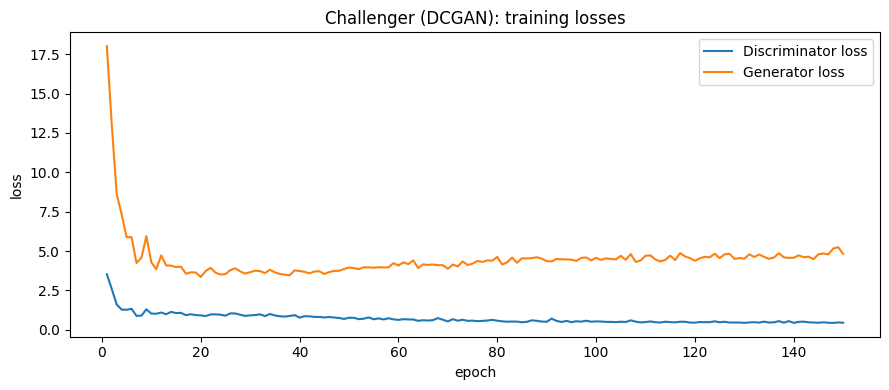

In [6]:
epochs_r, d_losses_r, g_losses_r = zip(*history)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_r, d_losses_r, label="Discriminator loss")
ax.plot(epochs_r, g_losses_r, label="Generator loss")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
ax.set_title("Challenger (DCGAN): training losses")
plt.tight_layout()
plt.savefig("../img/gan_training_curves.png")
plt.show()

## Generate a final qualitative sample grid across classes (same layout as the LoRA champion's)

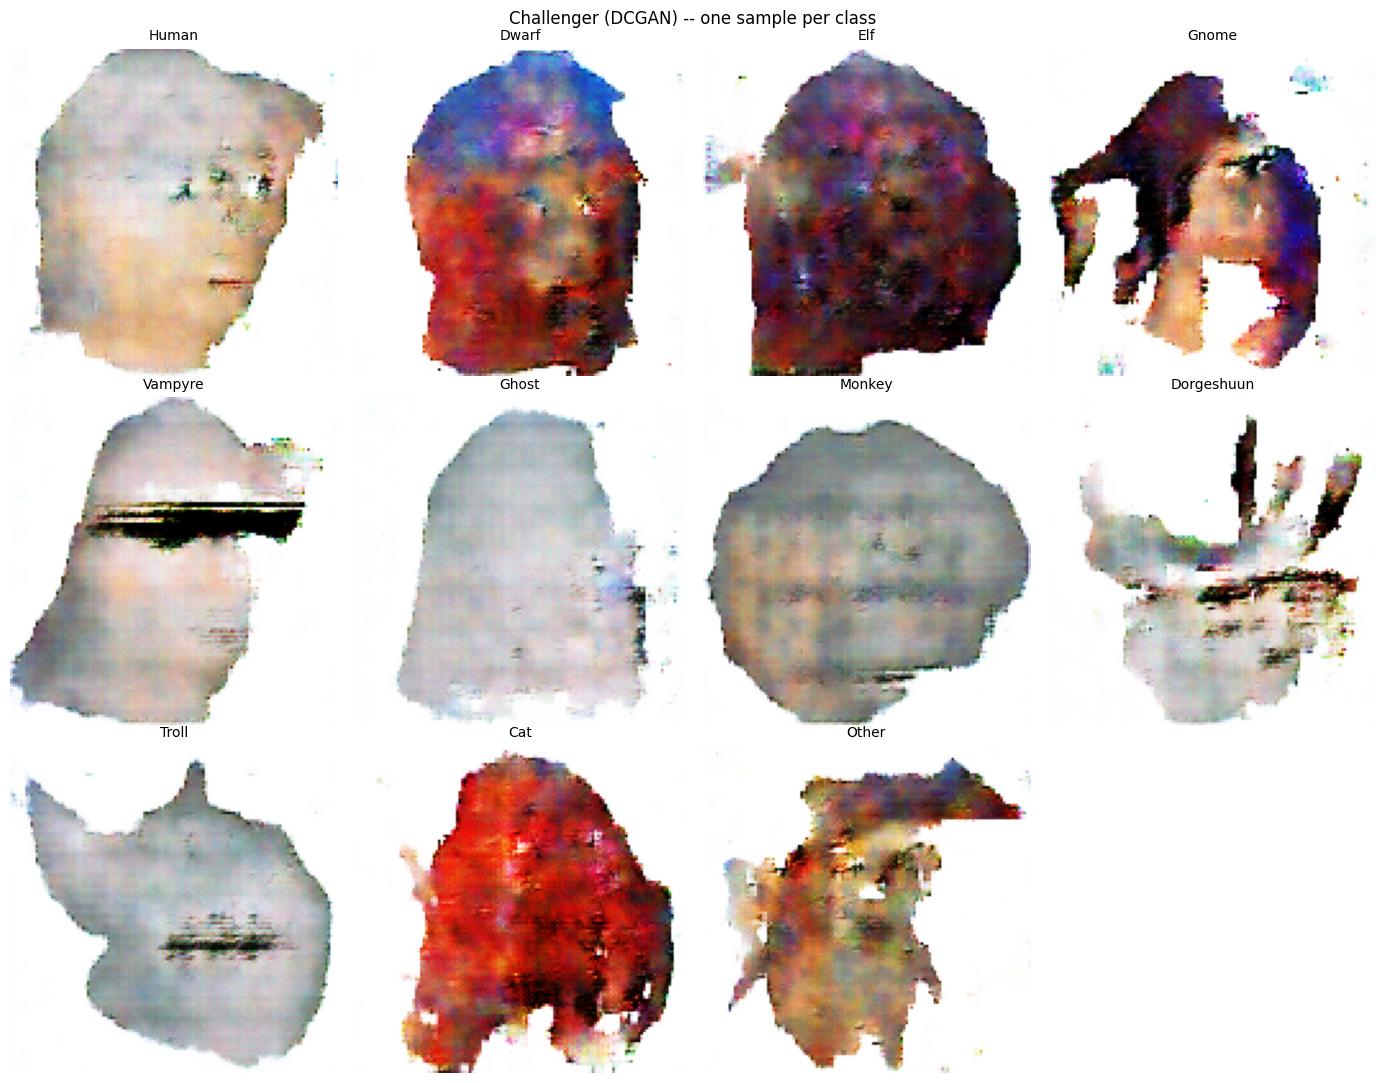

In [7]:
netG.eval()
generator_rng = torch.Generator(device=DEVICE).manual_seed(42)

samples = {}
with torch.no_grad():
    for i, cls in enumerate(CLASS_NAMES):
        z = torch.randn(1, Z_DIM, device=DEVICE, generator=generator_rng)
        label = torch.tensor([i], device=DEVICE)
        img_t = netG(z, label).cpu().squeeze(0)
        img_t = (img_t * 0.5 + 0.5).clamp(0, 1)
        samples[cls] = transforms.ToPILImage()(img_t)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, cls in zip(axes.flat, CLASS_NAMES):
    ax.imshow(samples[cls])
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(CLASS_NAMES):]:
    ax.axis("off")
plt.suptitle("Challenger (DCGAN) -- one sample per class")
plt.tight_layout()
plt.savefig("../img/gan_challenger_samples.png")
plt.show()

In [8]:
SAMPLES_DIR = "../data/gan_challenger_samples"
os.makedirs(SAMPLES_DIR, exist_ok=True)
for cls, img in samples.items():
    img.save(f"{SAMPLES_DIR}/{cls}.png")
print(f"Saved {len(samples)} sample images to {SAMPLES_DIR}")

Saved 11 sample images to ../data/gan_challenger_samples
